# Standard pH Calibration  (pH 1 - 12)

Calibrate a glass pH electrode and convert measured EMF into pH.
The response is assumed **linear (Nernstian)**:

$$\text{EMF} = E_0 - S\cdot \text{pH}$$

Choose one of two options:

- **Option 1 - pH at a SPECIFIC temperature.** Calibrate with buffers measured at one
  temperature, then predict sample pH at that same temperature.
- **Option 2 - pH at ANY temperature.** Calibrate with buffers measured at several
  temperatures; the notebook fits $E_0(T)$ and $S(T)$ so you can predict pH at any
  temperature in the calibrated range.

All input is via **inline arrays** - just edit the values in the marked cells and run.

*From Saleesongsom et al., ACS Omega (2026).*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

np.set_printoptions(suppress=True)


---
## Option 1 - pH at a specific temperature

### Step 1. Build the calibration
Enter buffer pH / EMF pairs measured at a single temperature (>= 2 points, 3+ better).


Calibration @ 24.4 C:  EMF = 417.58 - 58.741 * pH
  slope S = 58.741 mV/pH   E0 = 417.58 mV   R^2 = 1.00000
  theoretical Nernst slope = 59.040 mV/pH  (99.5% Nernstian)


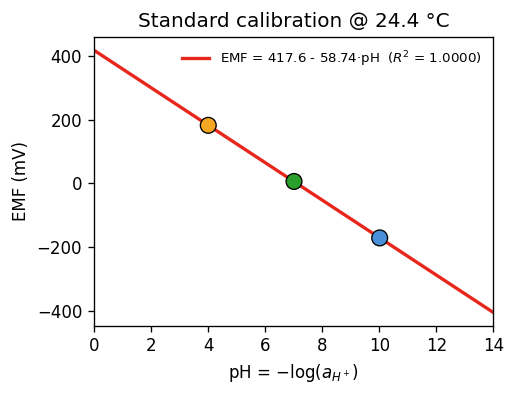

In [2]:
# ===== EDIT YOUR NIST/DIN BUFFER DATA (single temperature) =====
# Standard pH calibration uses NIST/DIN buffers at pH 4, 7 and 10.
# Example = real 3-point calibration at ~24.4 C (this study).
buffer_pH  = [4.009, 7.013, 10.015]   # NIST/DIN buffer pH values
buffer_EMF = [181.9, 6.0, -170.9]     # measured EMF (mV)
T_C        = 24.4                      # measurement temperature (deg C)
# ===============================================================

buffer_pH  = np.asarray(buffer_pH,  float)
buffer_EMF = np.asarray(buffer_EMF, float)

slope, intercept, r, p, se = stats.linregress(buffer_pH, buffer_EMF)
S1, E0_1, r2_1 = -slope, intercept, r**2
S_theory = 2.302585 * 8.314462 * (T_C + 273.15) / 96485.0 * 1000.0  # mV/pH

print(f"Calibration @ {T_C} C:  EMF = {E0_1:.2f} - {S1:.3f} * pH")
print(f"  slope S = {S1:.3f} mV/pH   E0 = {E0_1:.2f} mV   R^2 = {r2_1:.5f}")
print(f"  theoretical Nernst slope = {S_theory:.3f} mV/pH  ({100*S1/S_theory:.1f}% Nernstian)")

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=120)
xl = np.array([0, 14])
ax.plot(xl, E0_1 - S1 * xl, "-", color="#E8261C", lw=2.0,
        label=f"EMF = {E0_1:.1f} - {S1:.2f}·pH  ($R^2$ = {r2_1:.4f})")
buf_colors = ["#F5A623", "#2CA02C", "#4A90D9"]   # pH 4 (orange), 7 (green), 10 (blue)
cvals = buf_colors if len(buffer_pH) == 3 else "#F5A623"
ax.scatter(buffer_pH, buffer_EMF, s=90, c=cvals, edgecolors="black",
           linewidths=0.8, zorder=3)
ax.set_xlim(0, 14)
ax.set_xlabel(r"pH = $-\log(a_{H^+})$"); ax.set_ylabel("EMF (mV)")
ax.legend(fontsize=8, frameon=False); ax.set_title(f"Standard calibration @ {T_C} °C")
plt.tight_layout(); plt.show()


### Step 2. Predict sample pH
Enter the EMF of your sample(s) measured at the same temperature.
$$\text{pH} = (E_0 - \text{EMF})/S$$


In [3]:
# ============ EDIT YOUR SAMPLE EMF (same temperature) ============
sample_EMF = [120.0, 30.0, -60.0]     # measured EMF (mV)
# =================================================================

sample_EMF = np.atleast_1d(np.asarray(sample_EMF, float))
sample_pH  = (E0_1 - sample_EMF) / S1

print(f"Predicted pH @ {T_C} C:")
for e, ph in zip(sample_EMF, sample_pH):
    print(f"  EMF {e:8.2f} mV  ->  pH {ph:6.3f}")


Predicted pH @ 24.4 C:
  EMF   120.00 mV  ->  pH  5.066
  EMF    30.00 mV  ->  pH  6.598
  EMF   -60.00 mV  ->  pH  8.130


---
## Option 2 - pH at any temperature (temperature-corrected)

Standard 3-point calibrations are run at several temperatures to extract the
Nernstian slope $S$ and standard potential $E_0$ at each temperature. Their
temperature dependence is then obtained by **linear regression**:

$$S(T) = K_s\,(T+273.15) + C \qquad\text{(slope from linear regression on the Kelvin scale)}$$

$$E_0(T) = E_{0,25} + \dfrac{dE_0}{dT}\,(T-25) \qquad\text{(intercept centered at 25 °C)}$$

giving the practical temperature-dependent Nernst response

$$\text{EMF}(\text{pH},T) = E_0(T) - S(T)\cdot\text{pH}.$$

For the example dataset the fitted values are about $K_s = 0.199$ mV·°C⁻¹·pH⁻¹, $C = -0.54$ mV·pH⁻¹,
$E_{0,25} = 418.9$ mV, $dE_0/dT = 1.13$ mV·°C⁻¹.

### Step 1. Load standard calibrations at several temperatures
The multi-temperature data live in the companion workbook
**`calibration_datasets.xlsx`** (sheet **`Standard`**) so the notebook stays tidy.
Columns: `Temperature_C | pH | EMF_mV` - a 3-point NIST/DIN buffer calibration
(pH 4, 7, 10) at each temperature. Edit that sheet to use your own data.
The example is this study's real 6.8-57.8 °C dataset. The plot shows the raw EMF
response coloured by temperature (no fit yet).


In [4]:
# ===== LOAD STANDARD DATA FROM EXCEL (edit the .xlsx, not this cell) =====
std_df = pd.read_excel("calibration_datasets.xlsx", sheet_name="Standard")
# group into  temperature_C : ( [buffer pH], [measured EMF] )
calibration_data = {float(T): (g["pH"].to_numpy(float), g["EMF_mV"].to_numpy(float))
                    for T, g in std_df.groupby("Temperature_C")}
temps = np.array(sorted(calibration_data), float)
print(f"{len(calibration_data)} temperatures loaded from Excel:",
      [round(t, 2) for t in temps])

# shared flat arrays + temperature colour scale (autumn_r)
pH_all  = std_df["pH"].to_numpy(float)
emf_all = std_df["EMF_mV"].to_numpy(float)
T_all   = std_df["Temperature_C"].to_numpy(float)
CMAP    = plt.cm.autumn_r
tnorm   = mpl.colors.Normalize(temps.min(), temps.max())
XLABEL  = r"pH = $-\log(a_{H^+})$"
# ========================================================================

7 temperatures loaded from Excel: [np.float64(6.81), np.float64(15.89), np.float64(24.41), np.float64(31.5), np.float64(38.89), np.float64(48.31), np.float64(57.8)]


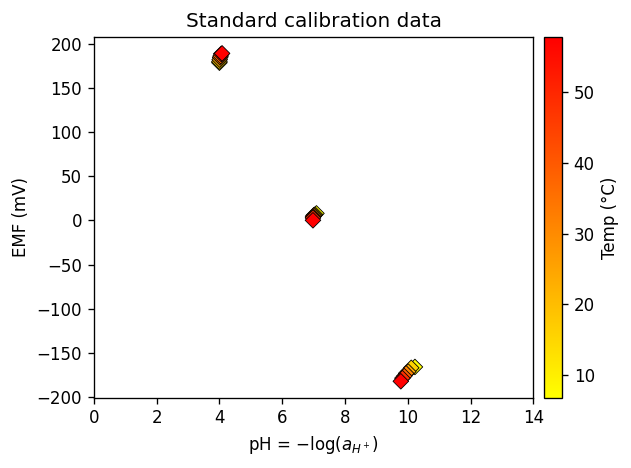

In [5]:
# ---- Plot the raw calibration data, coloured by temperature (no fit) ----
fig, ax = plt.subplots(figsize=(5.4, 4.0), dpi=120)
sc = ax.scatter(pH_all, emf_all, c=T_all, cmap=CMAP, norm=tnorm,
                marker="D", s=44, edgecolors="k", linewidths=0.5, zorder=3)
fig.colorbar(sc, ax=ax, pad=0.02).set_label("Temp (°C)")
ax.set_xlim(0, 14)
ax.set_xlabel(XLABEL); ax.set_ylabel("EMF (mV)")
ax.set_title("Standard calibration data")
plt.tight_layout(); plt.show()


### Step 2. Fit the Nernst response at each temperature
A Nernst line $\text{EMF} = E_0 - S\cdot\text{pH}$ is fit to the buffers at every
temperature, giving one $(S, E_0)$ pair per temperature. The plot repeats Step 1
and overlays each fitted Nernst line, coloured by temperature.


In [6]:
# ---- Fit a Nernst line EMF = E0 - S*pH at each temperature ----
S_arr, E0_arr, nernst_fits = [], [], []
for T in temps:
    ph, emf = map(lambda a: np.asarray(a, float), calibration_data[T])
    sl, ic, r, *_ = stats.linregress(ph, emf)
    S_arr.append(-sl); E0_arr.append(ic); nernst_fits.append((T, ic, -sl))
    print(f"T = {T:5.1f} C   S = {-sl:6.3f} mV/pH   E0 = {ic:7.2f} mV   R^2 = {r**2:.5f}")
S_arr, E0_arr = np.asarray(S_arr), np.asarray(E0_arr)
print(f"\n{len(temps)} per-temperature Nernst fits feed the temperature model.")


T =   6.8 C   S = 55.244 mV/pH   E0 =  399.48 mV   R^2 = 1.00000
T =  15.9 C   S = 56.677 mV/pH   E0 =  406.28 mV   R^2 = 1.00000
T =  24.4 C   S = 58.741 mV/pH   E0 =  417.58 mV   R^2 = 1.00000
T =  31.5 C   S = 60.297 mV/pH   E0 =  427.02 mV   R^2 = 1.00000
T =  38.9 C   S = 61.863 mV/pH   E0 =  435.81 mV   R^2 = 1.00000
T =  48.3 C   S = 63.491 mV/pH   E0 =  445.90 mV   R^2 = 1.00000
T =  57.8 C   S = 65.115 mV/pH   E0 =  454.83 mV   R^2 = 1.00000

7 per-temperature Nernst fits feed the temperature model.


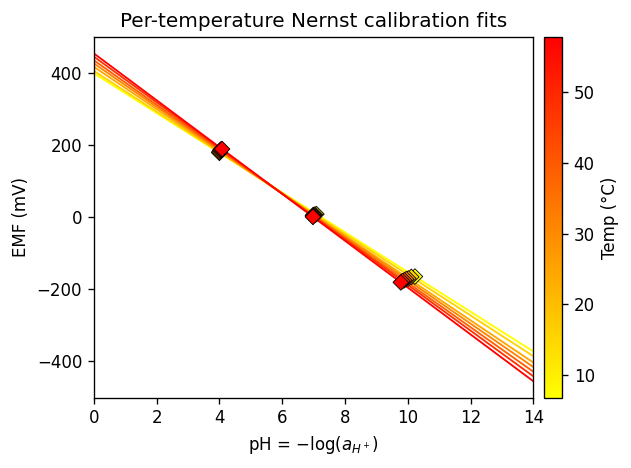

In [7]:
# ---- Calibration data + per-temperature Nernst fits ----
fig, ax = plt.subplots(figsize=(5.4, 4.0), dpi=120)
xf = np.linspace(0, 14, 200)
for T, E0i, Si in nernst_fits:
    ax.plot(xf, E0i - Si * xf, "-", color=CMAP(tnorm(T)), lw=1.1, zorder=2)
sc = ax.scatter(pH_all, emf_all, c=T_all, cmap=CMAP, norm=tnorm,
                marker="D", s=44, edgecolors="k", linewidths=0.5, zorder=3)
fig.colorbar(sc, ax=ax, pad=0.02).set_label("Temp (°C)")
ax.set_xlim(0, 14)
ax.set_xlabel(XLABEL); ax.set_ylabel("EMF (mV)")
ax.set_title("Per-temperature Nernst calibration fits")
plt.tight_layout(); plt.show()


### Step 3. Linear regression of S(T) and E0(T)
The slope and standard potential are fit by linear regression on temperature:

$$S(T) = K_s\,(T+273.15) + C \qquad E_0(T) = E_{0,25} + \dfrac{dE_0}{dT}\,(T-25).$$

The two panels show $S(T)$ and $E_0(T)$ with their 95% confidence bands.

In [8]:
# ---- Temperature models ----
# S(T)  = Ks*(T+273.15) + C      -> regress S on Kelvin
# E0(T) = E0_25 + dE0dT*(T-25)   -> regress E0 on (T-25)
cS = np.polyfit(temps + 273.15, S_arr, 1);  Ks, C = cS
cE = np.polyfit(temps - 25.0,  E0_arr, 1);  dE0dT, E0_25 = cE
S_of_T  = lambda T: Ks * (T + 273.15) + C
E0_of_T = lambda T: E0_25 + dE0dT * (T - 25.0)

def _r2(y, yh): return 1 - np.sum((y - yh)**2) / np.sum((y - np.mean(y))**2)
print(f"S(T)  = {Ks:.4f}·(T+273.15) + ({C:+.3f})       R^2 = {_r2(S_arr,  S_of_T(temps)):.4f}")
print(f"E0(T) = {E0_25:.2f} + ({dE0dT:+.4f})·(T-25)      R^2 = {_r2(E0_arr, E0_of_T(temps)):.4f}")


S(T)  = 0.1992·(T+273.15) + (-0.558)       R^2 = 0.9964
E0(T) = 418.84 + (+1.1319)·(T-25)      R^2 = 0.9956


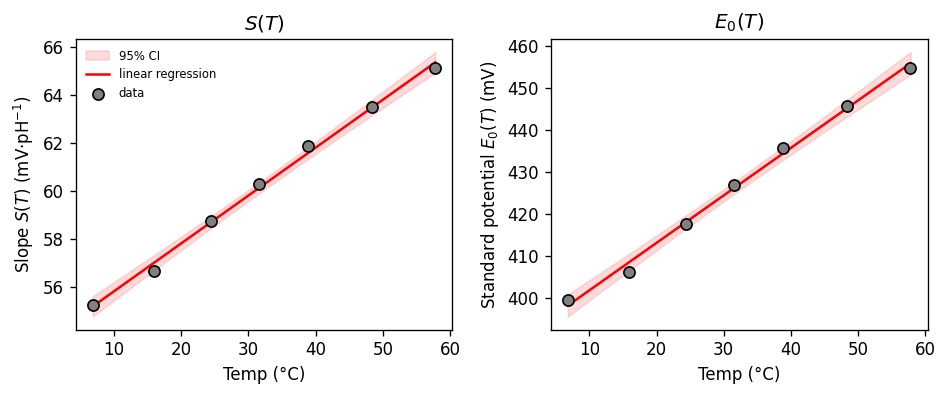

In [9]:
# ---- Linear-regression graphs (S vs T and E0 vs T) ----
def line_ci(xg, coeffs, xd, yd):
    '''95% confidence band on a degree-1 fit; returns (yhat, halfwidth).'''
    n = len(xd); dof = max(n - 2, 1)
    yhat = np.polyval(coeffs, xg)
    s2 = np.sum((yd - np.polyval(coeffs, xd))**2) / dof
    xbar = xd.mean(); Sxx = np.sum((xd - xbar)**2)
    se = np.sqrt(s2 * (1.0 / n + (xg - xbar)**2 / Sxx))
    return yhat, stats.t.ppf(0.975, dof) * se

Tg = np.linspace(temps.min(), temps.max(), 200)
fig, axs = plt.subplots(1, 2, figsize=(8, 3.4), dpi=120)

# (1) slope S(T)  -- linear regression on the Kelvin scale
yh, hw = line_ci(Tg + 273.15, cS, temps + 273.15, S_arr)
axs[0].fill_between(Tg, yh - hw, yh + hw, color="#ff9999", alpha=0.35, label="95% CI")
axs[0].plot(Tg, yh, "r-", lw=1.5, label="linear regression")
axs[0].scatter(temps, S_arr, s=45, c="0.5", edgecolors="k", zorder=3, label="data")
axs[0].set_xlabel("Temp (°C)"); axs[0].set_ylabel(r"Slope $S(T)$ (mV·pH$^{-1}$)")
axs[0].set_title("$S(T)$"); axs[0].legend(fontsize=7, frameon=False)

# (2) standard potential E0(T)  -- centered at 25 C
yh, hw = line_ci(Tg - 25.0, cE, temps - 25.0, E0_arr)
axs[1].fill_between(Tg, yh - hw, yh + hw, color="#ff9999", alpha=0.35)
axs[1].plot(Tg, yh, "r-", lw=1.5)
axs[1].scatter(temps, E0_arr, s=45, c="0.5", edgecolors="k", zorder=3)
axs[1].set_xlabel("Temp (°C)"); axs[1].set_ylabel(r"Standard potential $E_0(T)$ (mV)")
axs[1].set_title("$E_0(T)$")

plt.tight_layout(); plt.show()


### Step 4. Full standard-pH calibration with the temperature-dependent model
Combining $S(T)$ and $E_0(T)$ gives the complete calibration
$$\text{EMF}(\text{pH}, T) = E_0(T) - S(T)\cdot\text{pH}.$$
The family below (coloured by temperature) is the standard calibration used for
prediction.


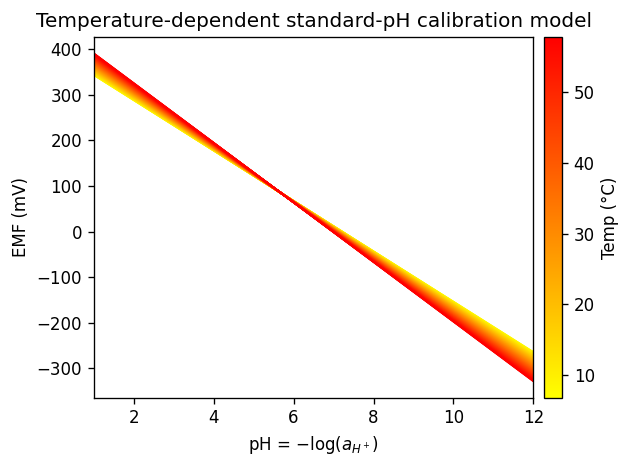

In [10]:
# ---- Full temperature-dependent calibration model EMF(pH, T) ----
pH_grid = np.linspace(1, 12, 300)
fig, ax = plt.subplots(figsize=(5.4, 4.0), dpi=120)
for T in np.linspace(temps.min(), temps.max(), 120):
    ax.plot(pH_grid, E0_of_T(T) - S_of_T(T) * pH_grid, color=CMAP(tnorm(T)), lw=1.1)
sm = mpl.cm.ScalarMappable(cmap=CMAP, norm=tnorm); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02).set_label("Temp (°C)")
ax.set_xlim(1, 12)
ax.set_xlabel(XLABEL); ax.set_ylabel("EMF (mV)")
ax.set_title("Temperature-dependent standard-pH calibration model")
plt.tight_layout(); plt.show()


### Step 5. Predict sample pH at any temperature
Enter each sample EMF **and** its temperature.
$$\text{pH} = \dfrac{E_0(T)-\text{EMF}}{S(T)}$$


In [11]:
# ============ EDIT YOUR SAMPLE MEASUREMENTS ============
sample_EMF = [150.0, 0.0, -150.0]     # measured EMF (mV)
sample_T   = [20.0, 30.0, 35.0]       # temperature of each sample (deg C)
# ======================================================

sample_EMF = np.atleast_1d(np.asarray(sample_EMF, float))
sample_T   = np.atleast_1d(np.asarray(sample_T, float))
if sample_T.size == 1:
    sample_T = np.full_like(sample_EMF, sample_T[0])

print("EMF (mV) @ T (C)  ->  predicted pH")
for e, T in zip(sample_EMF, sample_T):
    ph = (E0_of_T(T) - e) / S_of_T(T)
    warn = "  (T outside calibrated range)" if (T < temps.min() or T > temps.max()) else ""
    print(f"  {e:8.2f} @ {T:5.1f}  ->  pH {ph:6.3f}{warn}")


EMF (mV) @ T (C)  ->  predicted pH
    150.00 @  20.0  ->  pH  4.551
      0.00 @  30.0  ->  pH  7.097
   -150.00 @  35.0  ->  pH  9.540
